

---

#INTELIGENCIA ARTIFICIAL: PRIMER PARCIAL
ALUMNA: LARISSA MARIA BELEN RUIZ ALMIRON

CI: 5.350.940

CARRERA: MECATRONICA

MATERIA: INTELIGENCIA ARTIFICIAL

CICLO: 2026-2

# Análisis y predicción del éxito académico por carrera y asignatura en la FIUNA

**Dataset:** rendimiento académico de estudiantes de la FIUNA  
**Periodos:** 2024-2, 2025-1 y 2025-2  
**Plan académico:** Plan 2023 (`PLS23`)  
**Tipo de problema:** clasificación binaria  

## Pregunta
¿Qué asignaturas presentan mayor y menor éxito académico en cada carrera de la FIUNA para el Plan 2023?

## 1. Objetivo

### Objetivo general

Identificar las asignaturas con mayor y menor éxito académico estimado en cada carrera de la FIUNA.

### Objetivos específicos

1. Unificar los registros académicos de 2024-2, 2025-1 y 2025-2.
2. Seleccionar exclusivamente los registros del Plan 2023.
3. Analizar las características y calidad del dataset.
4. Preparar las variables académicas para los modelos.
5. Entrenar cuatro modelos de clasificación.
6. Comparar los modelos mediante Accuracy, Precision, Recall, F1-score y AUC-ROC.
7. Seleccionar el modelo con mejor desempeño.
8. Calcular la probabilidad promedio de aprobación por carrera y asignatura.
9. Identificar las asignaturas con mayor y menor éxito académico según las predicciones del mejor modelo.
10. Comparar las tasas predichas con las tasas reales para comprobar los resultados.

### Variable objetivo

La variable objetivo será `Aprobado`:

- `S = 1`: aprobado.
- `N = 0`: no aprobado.

### Unidad de análisis

Cada fila representa el resultado de un estudiante en una asignatura, carrera y periodo determinados.

## 2. Tipo de análisis

El proyecto cuenta con un análisis descriptivo previo  y un problema de clasificación supervisada.

El análisis descriptivo permitirá determinar cuáles asignaturas presentan las tasas de aprobación más altas y más bajas en cada carrera.

La clasificación supervisada permitirá predecir si un estudiante aprobará o no mediante cuatro modelos:

1. Regresión logística.
2. Árbol de decisión.
3. Random Forest.
4. Gradient Boosting.



In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# División y procesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Configuración
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

SEMILLA = 42


## 3. Carga de los datos

Se cargarán los tres archivos Excel correspondientes a los periodos 2024-2, 2025-1 y 2025-2.

Los archivos fueron incorporados al entorno de Google Colab y serán leídos mediante `pandas`.

In [4]:
# ============================================================
# 2. CARGAR LOS ARCHIVOS
# ============================================================

df_2024_2 = pd.read_excel(
    "/rendimiento_año_2024_ciclo_2_anon.xlsx"
)

df_2025_1 = pd.read_excel(
    "/rendimiento_año_2025_ciclo_1_anon.xlsx"
)

df_2025_2 = pd.read_excel(
    "/rendimiento_año_2025_ciclo_2_anon.xlsx"
)

print("Archivos cargados correctamente.\n")

print("2024-2:", df_2024_2.shape)
print("2025-1:", df_2025_1.shape)
print("2025-2:", df_2025_2.shape)

Archivos cargados correctamente.

2024-2: (24468, 28)
2025-1: (19407, 29)
2025-2: (20420, 28)


In [6]:
# ============================================================
# 3. AGREGAR EL PERIODO
# ============================================================

df_2024_2["Periodo"] = "2024-2"
df_2025_1["Periodo"] = "2025-1"
df_2025_2["Periodo"] = "2025-2"


In [8]:
# ============================================================
# 4. CONCATENAR LOS ARCHIVOS
# ============================================================

df = pd.concat(
    [df_2024_2, df_2025_1, df_2025_2],
    ignore_index=True
)

print("Dimensión del dataset completo:")
print(df.shape)

df.head()

Dimensión del dataset completo:
(64295, 30)


,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,Anho.Firma,Primer.Par,Segundo.Par,Tercer.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,Periodo,FirmaCalculada
0,FIUNA_ALUMNO_005925,13012,FISICA 3,CGF-PLS13,3,2,2024,2,0,N,0,33,43,0,40,100,0,40,40,10,10,0,1,1,0.000,28,0,NaN,2024-2,NaN
1,FIUNA_ALUMNO_007516,13012,FISICA 3,CGF-PLS13,3,2,2024,2,0,N,0,33,43,0,40,100,0,40,40,10,10,0,1,1,0.000,28,0,NaN,2024-2,NaN
2,FIUNA_ALUMNO_005493,13012,FISICA 3,ELE-PLS13,3,2,2024,2,0,N,0,5,10,0,20,80,0,40,40,10,10,0,1,0,0.000,0,0,NaN,2024-2,NaN
3,FIUNA_ALUMNO_007517,13012,FISICA 3,ELE-PLS13,3,2,2024,2,0,N,0,5,10,0,20,80,0,40,40,10,10,0,1,0,0.000,0,0,NaN,2024-2,NaN
4,FIUNA_ALUMNO_006375,13012,FISICA 3,CIV-PLS13,3,2,2024,2,0,N,0,30,30,0,50,100,0,40,40,10,10,0,1,1,0.000,14,0,NaN,2024-2,NaN


## 4. Selección del Plan 2023

El proyecto analizará exclusivamente los registros correspondientes al Plan 2023.

La columna `Cod.Car.Sec` contiene conjuntamente el código de la carrera y el plan académico. Se seleccionarán los registros que contengan `PLS23`.

In [9]:
# ============================================================
# 5. FILTRAR EL PLAN 2023
# ============================================================

# Eliminar espacios
df["Cod.Car.Sec"] = (
    df["Cod.Car.Sec"]
    .astype(str)
    .str.strip()
)

# Seleccionar el Plan 2023
df = df[
    df["Cod.Car.Sec"].str.contains(
        "PLS23",
        case=False,
        na=False
    )
].copy()

# Extraer solamente el código de carrera
df["Carrera"] = (
    df["Cod.Car.Sec"]
    .str.replace("-PLS23", "", regex=False)
    .str.strip()
)

print("Dimensión después de seleccionar PLS23:")
print(df.shape)

print("\nCarreras encontradas:")
print(sorted(df["Carrera"].unique()))

Dimensión después de seleccionar PLS23:
(27411, 31)

Carreras encontradas:
['CGF', 'CIV', 'ECA', 'ELE', 'IND', 'MCT', 'MEC']


In [10]:
# ============================================================
# 6. CREAR LA VARIABLE OBJETIVO
# ============================================================

df["Aprobado_bin"] = df["Aprobado"].map({
    "N": 0,
    "S": 1
})

print("Distribución de la variable objetivo:")
print(df["Aprobado_bin"].value_counts())

print("\nValores faltantes:")
print(df["Aprobado_bin"].isnull().sum())

Distribución de la variable objetivo:
Aprobado_bin
0    15191
1    12220
Name: count, dtype: int64

Valores faltantes:
0


*Nota: Después de seleccionar exclusivamente el Plan 2023, el dataset contiene 27.411 registros pertenecientes a siete carreras. La variable objetivo fue transformada a formato numérico. Los estudiantes no aprobados se representan mediante 0 y los aprobados mediante 1. La variable objetivo no presenta valores faltantes, por lo que todos los registros seleccionados pueden utilizarse en el análisis.*

In [11]:
# ============================================================
# 7. DIMENSIONES GENERALES
# ============================================================

print("Cantidad de registros:", len(df))

print(
    "Cantidad de estudiantes:",
    df["ALUMNO_ID"].nunique()
)

print(
    "Cantidad de asignaturas:",
    df["Cod.Asign"].nunique()
)

print(
    "Cantidad de carreras:",
    df["Carrera"].nunique()
)

print(
    "Cantidad de periodos:",
    df["Periodo"].nunique()
)

Cantidad de registros: 27411
Cantidad de estudiantes: 3271
Cantidad de asignaturas: 90
Cantidad de carreras: 7
Cantidad de periodos: 3


In [12]:
# ============================================================
# 8. TIPOS DE VARIABLES
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27411 entries, 13691 to 62866
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ALUMNO_ID       27411 non-null  object 
 1   Cod.Asign       27411 non-null  int64  
 2   Asignatura      27411 non-null  object 
 3   Cod.Car.Sec     27411 non-null  object 
 4   Cod.Curso       27411 non-null  int64  
 5   Convocatoria    27411 non-null  int64  
 6   Anho            27411 non-null  int64  
 7   Semestre        27411 non-null  int64  
 8   Doc.Firma       27411 non-null  int64  
 9   Aprobado        27411 non-null  object 
 10  Anho.Firma      27411 non-null  int64  
 11  Primer.Par      27411 non-null  int64  
 12  Segundo.Par     27411 non-null  int64  
 13  Tercer.Par      27411 non-null  int64  
 14  TPLab.          27411 non-null  int64  
 15  Lab.            27411 non-null  int64  
 16  Proy.           27411 non-null  int64  
 17  Pond.PP         27411 non-null  


---

# 5. Análisis exploratorio de datos

En esta sección analizaremos los Datos disponibes para el dataset y veremos de forma preliminar como se respondería la pregunta sin modelos entrenados

En esta sección se estudiarán:

- Dimensiones del dataset.
- Tipos de variables.
- Valores faltantes.
- Estadísticas principales.
- Distribución de aprobados y no aprobados.
- Tasas de aprobación por periodo y carrera.
- Asignaturas con mayor y menor éxito académico.

## 5.1. Valores faltantes

Los valores faltantes representan registros sin información en una determinada variable.

Se calculará la cantidad y el porcentaje de valores faltantes de cada columna.

In [14]:
# ============================================================
# 9. VALORES FALTANTES
# ============================================================

valores_faltantes = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

valores_faltantes = valores_faltantes[
    valores_faltantes["Cantidad"] > 0
].sort_values(
    "Cantidad",
    ascending=False
)

display(valores_faltantes)

,Cantidad,Porcentaje
FirmaCalculada,19739,72.011
Nota.Final,12695,46.314


## 5.2. Estadísticas principales

Se analizan las variables académicas que posteriormente pueden utilizarse para predecir la aprobación.

Las estadísticas incluyen media, desviación estándar, mínimo, cuartiles y máximo.

In [15]:
# ============================================================
# 11. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

variables_academicas = [
    "Primer.Par",
    "Segundo.Par",
    "TPLab.",
    "Lab.",
    "Proy.",
    "Firma"
]

display(
    df[variables_academicas]
    .describe()
    .transpose()
)

,count,mean,std,min,25%,50%,75%,max
Primer.Par,27411.000,41.928,28.575,0.000,19.000,42.000,64.000,100.000
Segundo.Par,27411.000,37.576,30.538,0.000,1.000,38.000,61.000,100.000
TPLab.,27411.000,45.169,38.630,0.000,0.000,48.000,81.000,100.000
Lab.,27411.000,25.378,41.703,0.000,0.000,0.000,80.000,100.000
Proy.,27411.000,2.594,6.218,0.000,0.000,0.000,0.000,30.000
Firma,27411.000,40.417,31.035,-1.000,0.000,50.000,65.000,100.000


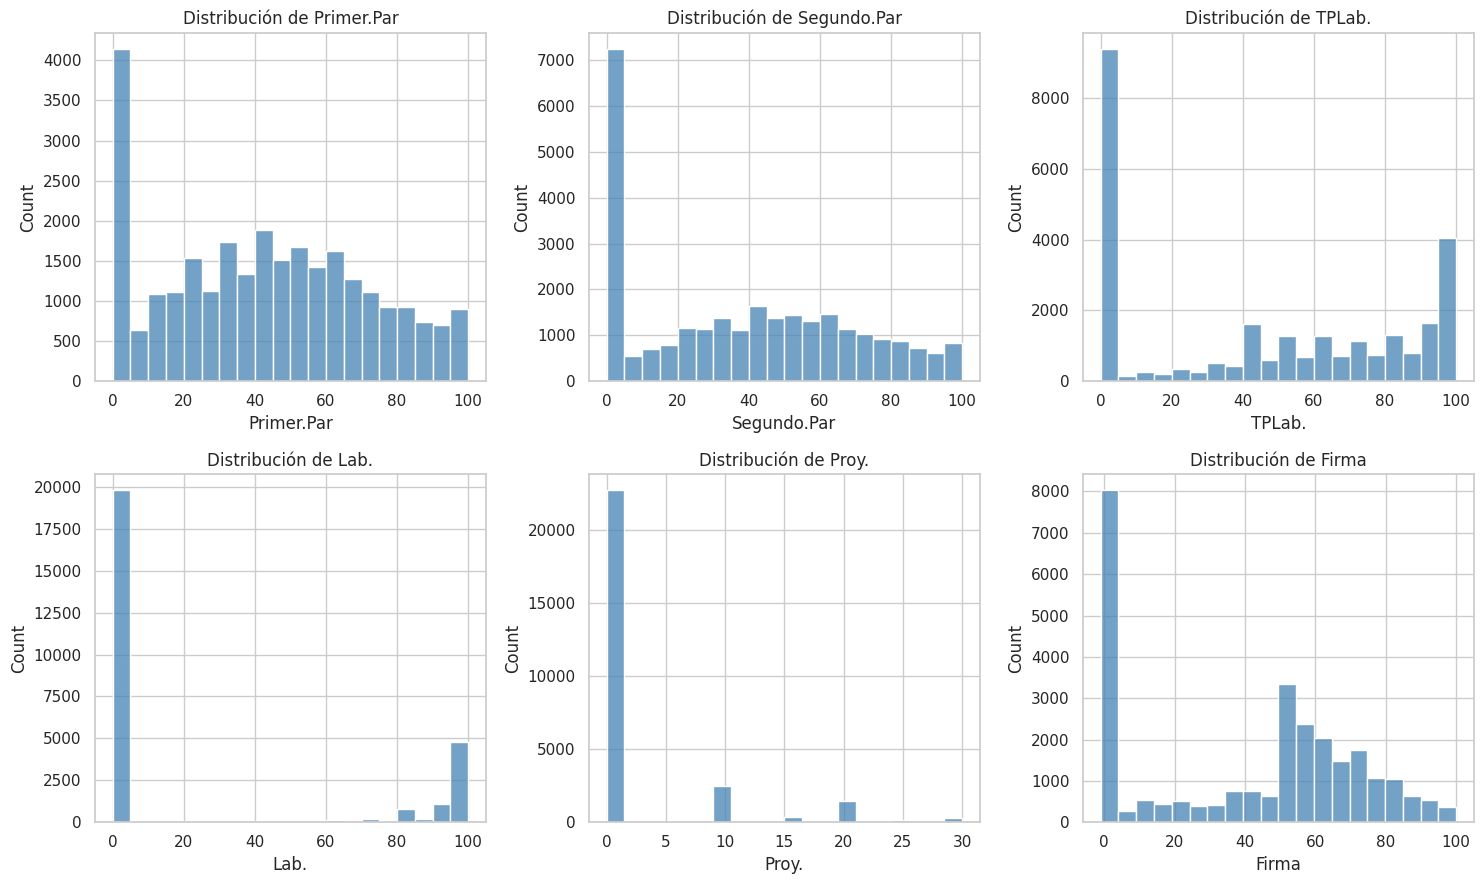

In [16]:
# ============================================================
# 12. DISTRIBUCIÓN DE CALIFICACIONES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, variable in enumerate(
    variables_academicas
):
    sns.histplot(
        data=df,
        x=variable,
        bins=20,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(
        f"Distribución de {variable}"
    )

plt.tight_layout()
plt.show()

## 5.3. Distribución de la variable objetivo

Se analiza la cantidad y el porcentaje de estudiantes aprobados y no aprobados.

Esta comprobación permite determinar si las clases están equilibradas.

,Cantidad,Porcentaje
Aprobado,,
N,15191,55.419
S,12220,44.581


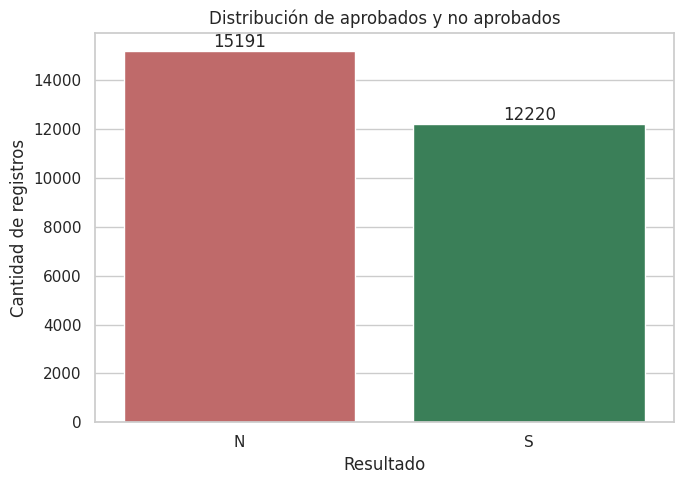

In [18]:
# ============================================================
# 13. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

distribucion_aprobados = pd.DataFrame({
    "Cantidad": df["Aprobado"].value_counts(),
    "Porcentaje":
        df["Aprobado"].value_counts(
            normalize=True
        ) * 100
})

display(distribucion_aprobados)

# Gráfico de aprobados y no aprobados

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Aprobado",
    order=["N", "S"],
    palette=[
        "indianred",
        "seagreen"
    ]
)

plt.title("Distribución de aprobados y no aprobados")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de registros")

for barra in ax.patches:
    cantidad = int(barra.get_height())

    ax.annotate(
        f"{cantidad}",
        (
            barra.get_x()
            + barra.get_width() / 2,
            cantidad
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 5.4. Tasa de aprobación por periodo

La tasa de aprobación se calculará mediante:

$$
\text{Tasa de aprobación}
=
\frac{\text{Cantidad de aprobados}}
{\text{Cantidad total de registros}}
\times 100
$$

Esta tasa se comparará entre 2024-2, 2025-1 y 2025-2.

,Periodo,Registros,Aprobados,Tasa_aprobacion,No_aprobados
0,2024-2,8895,3613,40.618,5282
1,2025-1,7672,3182,41.475,4490
2,2025-2,10844,5425,50.028,5419


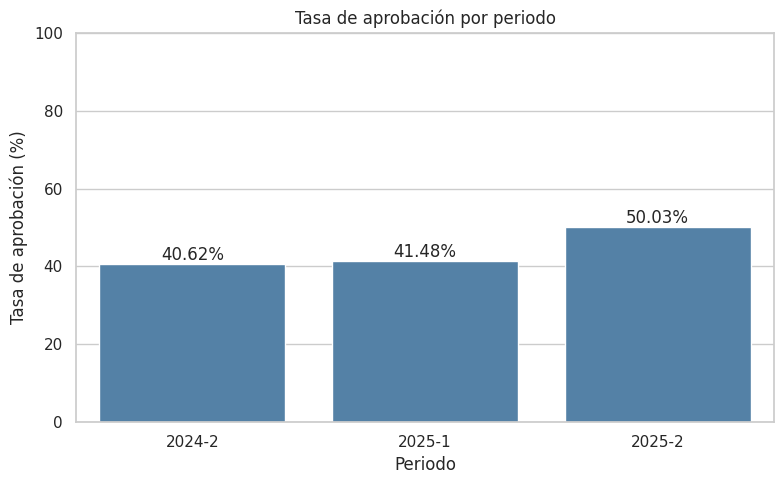

In [24]:
# ============================================================
# 14. TASA DE APROBACIÓN POR PERIODO
# ============================================================

resumen_periodo = (
    df.groupby("Periodo")
    .agg(
        Registros=("ALUMNO_ID", "size"),
        Aprobados=("Aprobado_bin", "sum"),
        Tasa_aprobacion=(
            "Aprobado_bin",
            "mean"
        )
    )
    .reset_index()
)

resumen_periodo["No_aprobados"] = (
    resumen_periodo["Registros"]
    - resumen_periodo["Aprobados"]
)

resumen_periodo["Tasa_aprobacion"] = (
    resumen_periodo["Tasa_aprobacion"] * 100
)

display(resumen_periodo)

# Gráfico de tasa de aprobación por periodo

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resumen_periodo,
    x="Periodo",
    y="Tasa_aprobacion",
    color="steelblue"
)

plt.title("Tasa de aprobación por periodo")
plt.xlabel("Periodo")
plt.ylabel("Tasa de aprobación (%)")
plt.ylim(0, 100)

for barra in ax.patches:
    tasa = barra.get_height()

    ax.annotate(
        f"{tasa:.2f}%",
        (
            barra.get_x()
            + barra.get_width() / 2,
            tasa
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 5.5. Tasa de aprobación por carrera

Se calcula la cantidad de registros, estudiantes y aprobados de cada carrera.

La tasa permite comparar carreras con diferentes cantidades de estudiantes.

,Carrera,Registros,Estudiantes,Aprobados,Tasa_aprobacion
2,ECA,768,132,438,57.031
5,MCT,2887,389,1503,52.061
1,CIV,12988,1556,5657,43.556
3,ELE,5878,740,2553,43.433
4,IND,2678,397,1156,43.167
6,MEC,918,170,382,41.612
0,CGF,1294,350,531,41.036


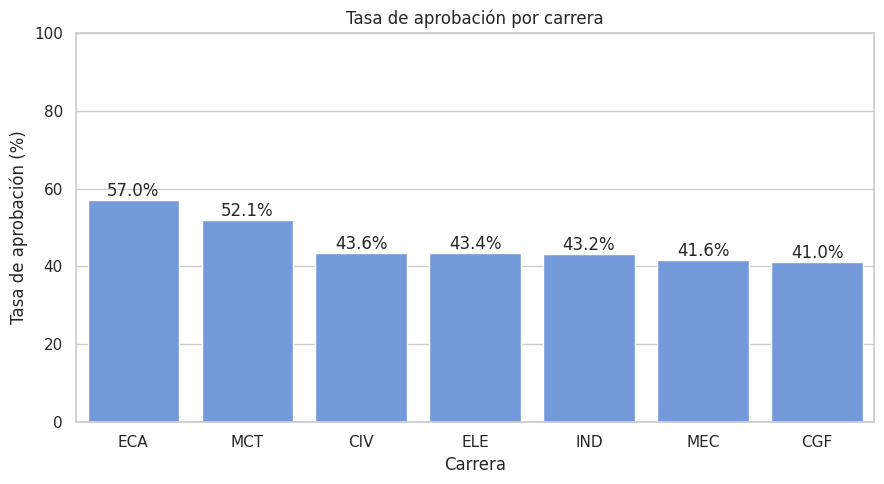

In [26]:
# ============================================================
# 15. TASA DE APROBACIÓN POR CARRERA
# ============================================================

resumen_carrera = (
    df.groupby("Carrera")
    .agg(
        Registros=("ALUMNO_ID", "size"),
        Estudiantes=("ALUMNO_ID", "nunique"),
        Aprobados=("Aprobado_bin", "sum"),
        Tasa_aprobacion=(
            "Aprobado_bin",
            "mean"
        )
    )
    .reset_index()
)

resumen_carrera["Tasa_aprobacion"] = (
    resumen_carrera["Tasa_aprobacion"] * 100
)

resumen_carrera = resumen_carrera.sort_values(
    "Tasa_aprobacion",
    ascending=False
)

display(resumen_carrera)

# Gráfico de tasa de aprobación por carrera

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumen_carrera,
    x="Carrera",
    y="Tasa_aprobacion",
    color="cornflowerblue"
)

plt.title("Tasa de aprobación por carrera")
plt.xlabel("Carrera")
plt.ylabel("Tasa de aprobación (%)")
plt.ylim(0, 100)

for barra in ax.patches:
    tasa = barra.get_height()

    ax.annotate(
        f"{tasa:.1f}%",
        (
            barra.get_x()
            + barra.get_width() / 2,
            tasa
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 5.6. Asignaturas con mayor y menor éxito por carrera

Como parte del análisis exploratorio, se calculan las tasas reales de aprobación por carrera y asignatura.

Este análisis permite conocer el comportamiento observado en el dataset y servirá posteriormente para comprobar las tasas estimadas por el mejor modelo.

Se utiliza un mínimo de 20 registros por combinación carrera–asignatura. Esto evita destacar materias con tasas de 0 % o 100 % calculadas a partir de muy pocos estudiantes.

In [27]:
# ============================================================
# 16. RESULTADOS POR CARRERA Y ASIGNATURA
# ============================================================

resumen_materias = (
    df.groupby(
        [
            "Carrera",
            "Cod.Asign",
            "Asignatura"
        ]
    )
    .agg(
        Registros=("ALUMNO_ID", "size"),
        Aprobados=("Aprobado_bin", "sum"),
        Tasa_aprobacion=(
            "Aprobado_bin",
            "mean"
        )
    )
    .reset_index()
)

resumen_materias["Tasa_aprobacion"] = (
    resumen_materias["Tasa_aprobacion"] * 100
)

resumen_materias["No_aprobados"] = (
    resumen_materias["Registros"]
    - resumen_materias["Aprobados"]
)

print(
    "Cantidad de combinaciones carrera-asignatura:",
    len(resumen_materias)
)

display(resumen_materias.head())

Cantidad de combinaciones carrera-asignatura: 199


,Carrera,Cod.Asign,Asignatura,Registros,Aprobados,Tasa_aprobacion,No_aprobados
0,CGF,23011,MECANICA Y CALOR,38,5,13.158,33
1,CGF,23012,CALCULO 1,64,8,12.500,56
2,CGF,23013,GEOMETRIA VECTORIAL,28,13,46.429,15
3,CGF,23014,ALGEBRA MODERNA,20,8,40.000,12
4,CGF,23015,GEOMETRIA DESCRIPTIVA,52,19,36.538,33


In [28]:
# ============================================================
# 17. FILTRAR MATERIAS CON POCOS REGISTROS
# ============================================================

MINIMO_REGISTROS = 20

resumen_materias_validas = (
    resumen_materias[
        resumen_materias["Registros"]
        >= MINIMO_REGISTROS
    ]
    .copy()
)

print(
    "Materias antes del filtro:",
    len(resumen_materias)
)

print(
    "Materias después del filtro:",
    len(resumen_materias_validas)
)

Materias antes del filtro: 199
Materias después del filtro: 174


CARRERA: CGF

Materias con mayor éxito:


,Asignatura,Registros,Aprobados,Tasa_aprobacion
23,TOPOGRAFIA 2,26,26,100.000
28,SOCIOLOGIA,28,28,100.000
21,TOPOGRAFIA 1,28,28,100.000
26,FOTOGRAMETRIA 2,28,28,100.000
20,FOTOGRAMETRIA 1,46,46,100.000



Materias con menor éxito:


,Asignatura,Registros,Aprobados,Tasa_aprobacion
11,ELECTRICIDAD Y MAGNETISMO,74,4,5.405
6,OPTICA Y ONDAS,52,6,11.538
1,CALCULO 1,64,8,12.500
0,MECANICA Y CALOR,38,5,13.158
15,METODOS NUMERICOS,90,16,17.778


CARRERA: CIV

Materias con mayor éxito:


...

,Asignatura,Registros,Aprobados,Tasa_aprobacion
155,METODOS NUMERICOS,90,24,26.667
150,ELECTRICIDAD Y MAGNETISMO,170,48,28.235
154,ESTATICA,214,62,28.972
143,CALCULO 1,223,71,31.839
142,MECANICA Y CALOR,173,67,38.728


CARRERA: MEC

Materias con mayor éxito:


,Asignatura,Registros,Aprobados,Tasa_aprobacion
194,MATERIALES DE INGENIERIA 1,22,22,100.000
174,ALGEBRA MODERNA,30,24,80.000
197,MECANISMOS,20,14,70.000
173,GEOMETRIA VECTORIAL,30,21,70.000
180,FUNDAMENTOS DE PROGRAMACION,30,18,60.000



Materias con menor éxito:


,Asignatura,Registros,Aprobados,Tasa_aprobacion
182,ELECTRICIDAD Y MAGNETISMO,68,4,5.882
191,MECANICA DE MATERIALES 1,46,4,8.696
187,METODOS NUMERICOS,44,10,22.727
177,OPTICA Y ONDAS,32,8,25.000
184,PROBABILIDAD,56,16,28.571


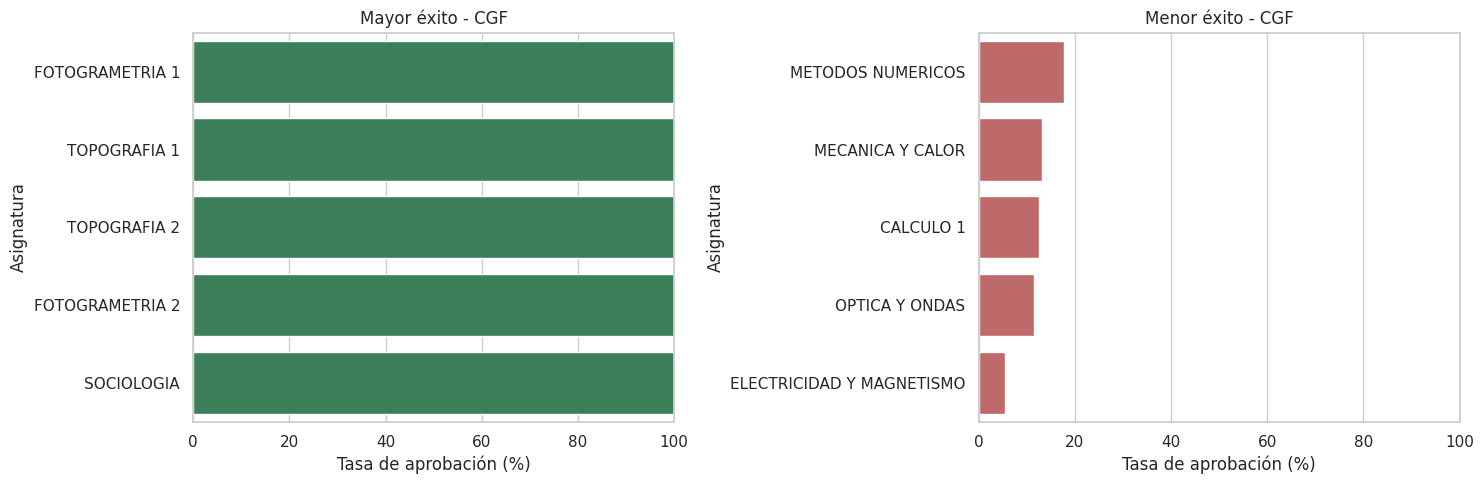

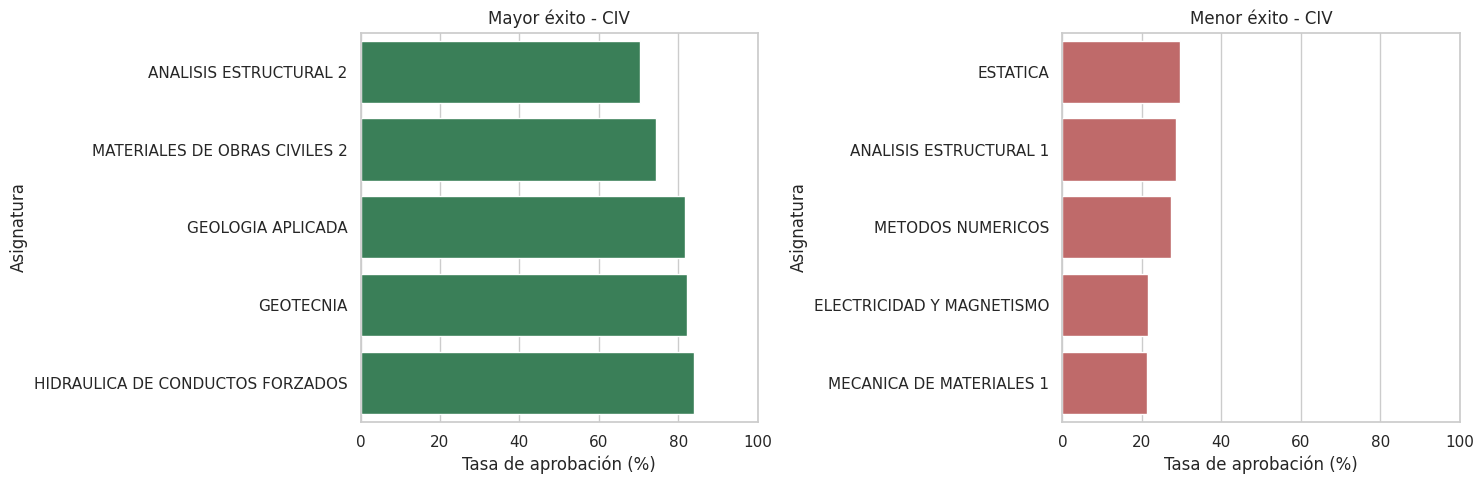

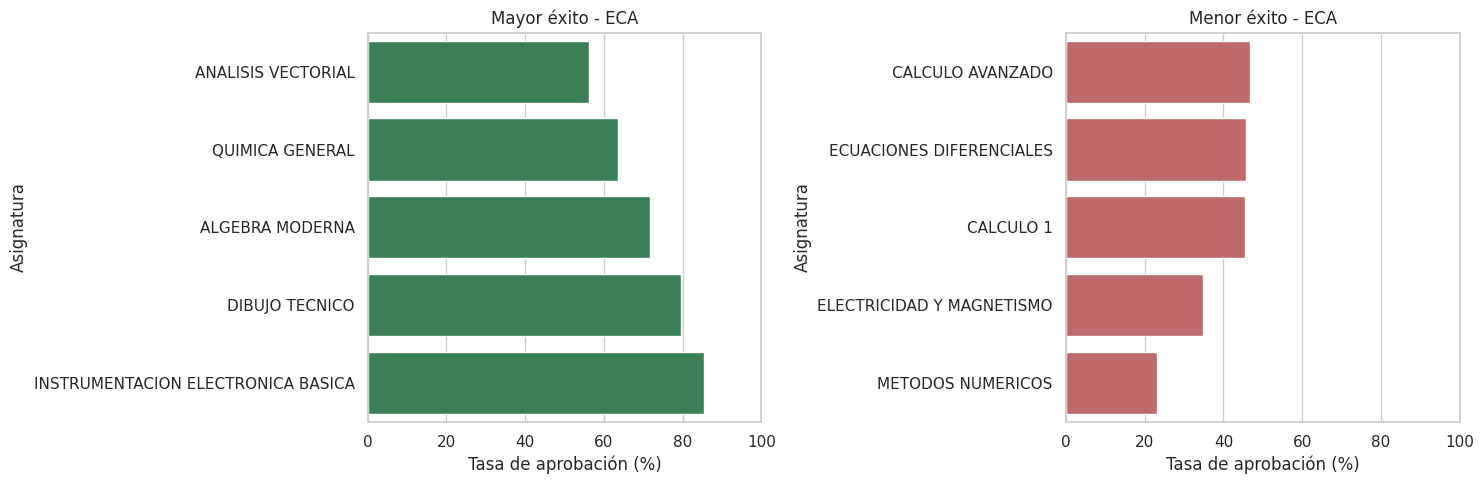

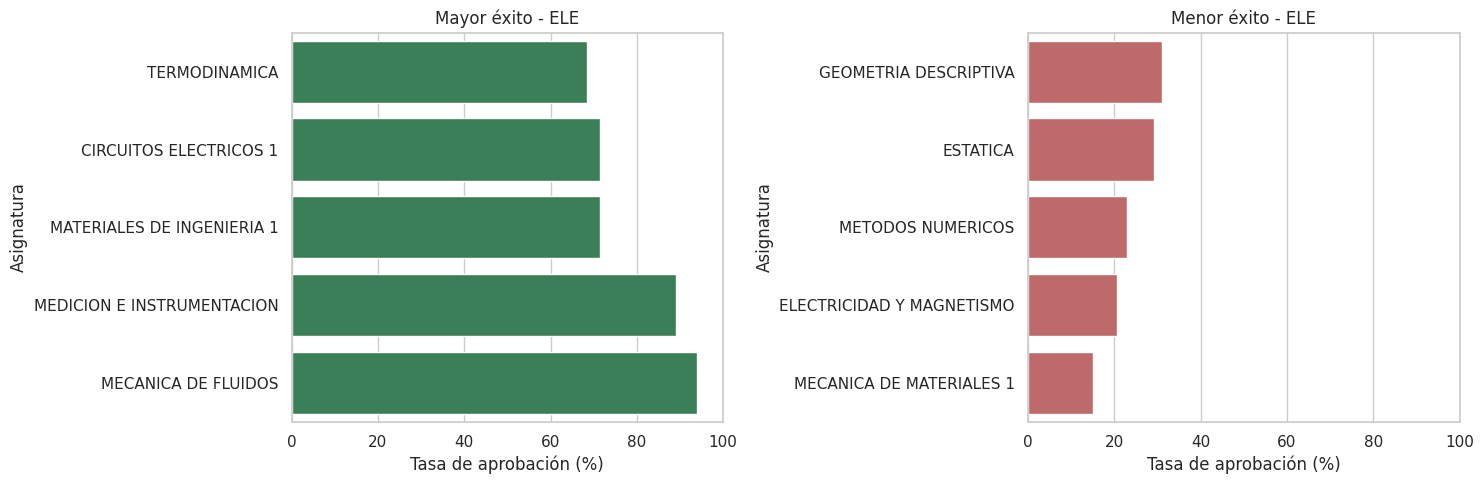

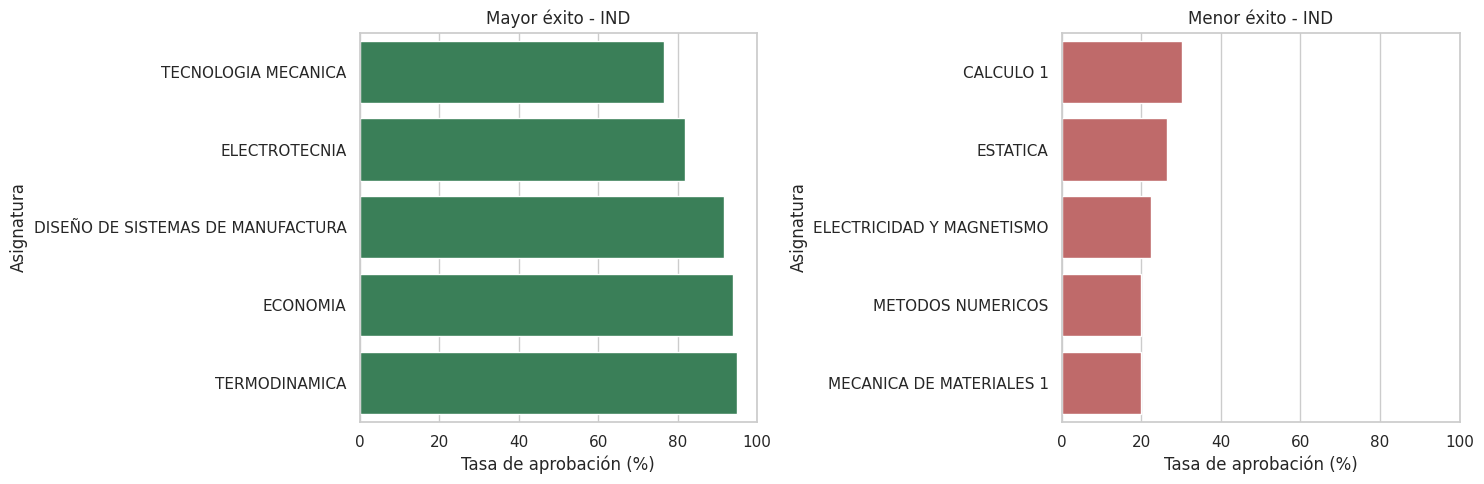

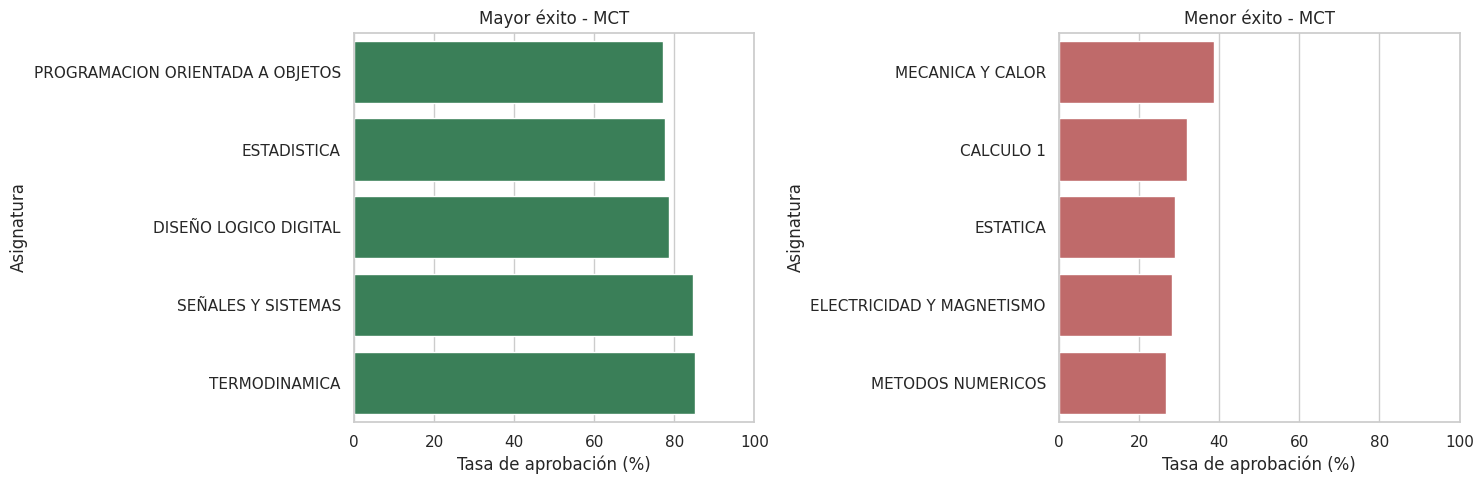

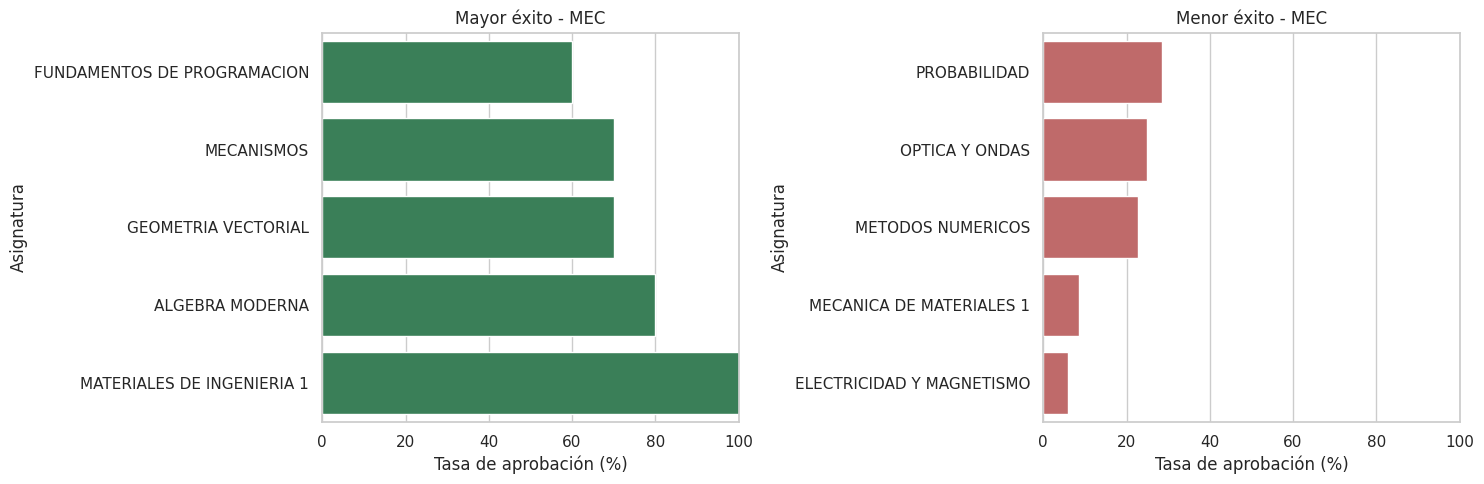

In [30]:
# ============================================================
# 18. MAYOR Y MENOR ÉXITO POR CARRERA
# ============================================================

for carrera in sorted(
    resumen_materias_validas[
        "Carrera"
    ].unique()
):
    datos_carrera = resumen_materias_validas[
        resumen_materias_validas["Carrera"]
        == carrera
    ]

    mayor_exito = (
        datos_carrera
        .sort_values(
            "Tasa_aprobacion",
            ascending=False
        )
        .head(5)
    )

    menor_exito = (
        datos_carrera
        .sort_values(
            "Tasa_aprobacion",
            ascending=True
        )
        .head(5)
    )

    print("=" * 70)
    print(f"CARRERA: {carrera}")
    print("=" * 70)

    print("\nMaterias con mayor éxito:")

    display(
        mayor_exito[
            [
                "Asignatura",
                "Registros",
                "Aprobados",
                "Tasa_aprobacion"
            ]
        ]
    )

    print("\nMaterias con menor éxito:")

    display(
        menor_exito[
            [
                "Asignatura",
                "Registros",
                "Aprobados",
                "Tasa_aprobacion"
            ]
        ]
    )

# ============================================================
# 19. GRÁFICOS DE ASIGNATURAS POR CARRERA
# ============================================================

for carrera in sorted(
    resumen_materias_validas[
        "Carrera"
    ].unique()
):
    datos_carrera = resumen_materias_validas[
        resumen_materias_validas["Carrera"]
        == carrera
    ]

    mayor_exito = (
        datos_carrera
        .nlargest(5, "Tasa_aprobacion")
        .sort_values("Tasa_aprobacion")
    )

    menor_exito = (
        datos_carrera
        .nsmallest(5, "Tasa_aprobacion")
        .sort_values(
            "Tasa_aprobacion",
            ascending=False
        )
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    sns.barplot(
        data=mayor_exito,
        x="Tasa_aprobacion",
        y="Asignatura",
        color="seagreen",
        ax=axes[0]
    )

    axes[0].set_title(
        f"Mayor éxito - {carrera}"
    )
    axes[0].set_xlabel(
        "Tasa de aprobación (%)"
    )
    axes[0].set_ylabel("Asignatura")
    axes[0].set_xlim(0, 100)

    sns.barplot(
        data=menor_exito,
        x="Tasa_aprobacion",
        y="Asignatura",
        color="indianred",
        ax=axes[1]
    )

    axes[1].set_title(
        f"Menor éxito - {carrera}"
    )
    axes[1].set_xlabel(
        "Tasa de aprobación (%)"
    )
    axes[1].set_ylabel("Asignatura")
    axes[1].set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

## 5.7. Interpretación del análisis exploratorio

El dataset del Plan 2023 contiene 27.411 registros, correspondientes a 3.271 estudiantes, 90 asignaturas, siete carreras y tres periodos académicos.

El 44,58 % de los registros corresponde a estudiantes aprobados y el 55,42 % a estudiantes no aprobados. La diferencia entre las clases no es extrema.

La tasa de aprobación aumentó de 40,62 % en 2024-2 a 50,03 % en 2025-2. También se observaron diferencias entre carreras y asignaturas.

Para identificar las asignaturas con mayor y menor éxito se consideraron solamente combinaciones carrera–asignatura con al menos 20 registros. Esto permite evitar conclusiones basadas en muestras demasiado pequeñas.

Una menor tasa de aprobación indica menor éxito académico durante los periodos analizados, pero no demuestra por sí sola que una materia sea intrínsecamente más difícil.

---
# 6. Procesamiento de datos

En esta sección se prepararán los datos para los modelos de Machine Learning.



## 6.1. Selección de variables

La predicción se realizará utilizando información académica disponible antes del resultado del examen final.

### Variables de contexto

- `Carrera`
- `Cod.Asign`
- `Cod.Curso`
- `Convocatoria`
- `Anho`
- `Semestre`

### Variables de evaluación

- `Primer.Par`
- `Segundo.Par`
- `TPLab.`
- `Lab.`
- `Proy.`
- `Firma`

### Variable objetivo

- `Aprobado_bin`

No se utilizarán `Nota.Final`, `Primer.Rec` ni `Segundo.Rec`, porque contienen información del examen final o de instancias posteriores.

Tampoco se utilizará `ALUMNO_ID`, porque funciona como identificador y no como característica académica.

In [32]:
# ============================================================
# 20. SELECCIONAR VARIABLES
# ============================================================

variables_numericas = [
    "Cod.Curso",
    "Convocatoria",
    "Anho",
    "Semestre",
    "Primer.Par",
    "Segundo.Par",
    "TPLab.",
    "Lab.",
    "Proy.",
    "Firma"
]

variables_categoricas = [
    "Carrera",
    "Cod.Asign"
]

variable_objetivo = "Aprobado_bin"

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nVariable objetivo:")
print(variable_objetivo)

Variables numéricas:
['Cod.Curso', 'Convocatoria', 'Anho', 'Semestre', 'Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.', 'Proy.', 'Firma']

Variables categóricas:
['Carrera', 'Cod.Asign']

Variable objetivo:
Aprobado_bin


In [33]:
# ============================================================
# 21. CREAR EL DATASET PARA LOS MODELOS
# ============================================================

columnas_modelo = (
    variables_numericas
    + variables_categoricas
    + [variable_objetivo]
)

df_modelo = df[columnas_modelo].copy()

# El código de asignatura es una categoría
df_modelo["Cod.Asign"] = (
    df_modelo["Cod.Asign"].astype(str)
)

print("Dimensión del dataset para los modelos:")
print(df_modelo.shape)

display(df_modelo.head())

Dimensión del dataset para los modelos:
(27411, 13)


,Cod.Curso,Convocatoria,Anho,Semestre,Primer.Par,Segundo.Par,TPLab.,Lab.,Proy.,Firma,Carrera,Cod.Asign,Aprobado_bin
13691,1,1,2024,2,0,0,0,50,0,0.000,CIV,23011,0
13692,1,1,2024,2,0,0,0,50,0,0.000,CIV,23011,0
13693,1,1,2024,2,11,34,60,100,0,50.000,MCT,23011,0
13694,1,1,2024,2,11,34,60,100,0,50.000,MCT,23011,0
13695,1,1,2024,2,0,0,10,70,0,0.000,CIV,23011,0


## 6.2. Transformación de variables categóricas

Los modelos necesitan trabajar con valores numéricos.

Las variables `Carrera` y `Cod.Asign` se transformarán mediante One-Hot Encoding utilizando `pd.get_dummies()`.

Este procedimiento crea una columna binaria para cada categoría.

In [34]:
# ============================================================
# 23. DEFINIR X E y
# ============================================================

# Variables predictoras
X = df_modelo.drop(
    columns=[variable_objetivo]
)

# Transformar las variables categóricas
X = pd.get_dummies(
    X,
    columns=variables_categoricas,
    drop_first=False,
    dtype=int
)

# Variable objetivo
y = df_modelo[variable_objetivo]

print("Dimensión de X:")
print(X.shape)

print("\nDimensión de y:")
print(y.shape)

print("\nPrimeras variables de X:")
print(X.columns[:20].tolist())

Dimensión de X:
(27411, 107)

Dimensión de y:
(27411,)

Primeras variables de X:
['Cod.Curso', 'Convocatoria', 'Anho', 'Semestre', 'Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.', 'Proy.', 'Firma', 'Carrera_CGF', 'Carrera_CIV', 'Carrera_ECA', 'Carrera_ELE', 'Carrera_IND', 'Carrera_MCT', 'Carrera_MEC', 'Cod.Asign_23011', 'Cod.Asign_23012', 'Cod.Asign_23013']


## 6.3. Visualización mediante PCA

PCA permite reducir las variables a dos componentes principales para representar los datos en un gráfico.

PCA se utilizará solamente como herramienta de visualización. No será uno de los modelos de clasificación comparados.

Antes de aplicar PCA se escalarán las variables para evitar que aquellas con valores numéricos mayores tengan una influencia desproporcionada.

In [35]:
# ============================================================
# 24. APLICAR PCA
# ============================================================

# Escalar X para la visualización
escalador_pca = StandardScaler()

X_escalado_pca = escalador_pca.fit_transform(X)

# Reducir a dos componentes
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_escalado_pca)

# Porcentaje de varianza explicada
varianza_pca = (
    pca.explained_variance_ratio_ * 100
)

print("Dimensión original:")
print(X.shape)

print("\nDimensión después de PCA:")
print(X_pca.shape)

print("\nVarianza explicada:")

print(
    f"Componente 1: "
    f"{varianza_pca[0]:.2f}%"
)

print(
    f"Componente 2: "
    f"{varianza_pca[1]:.2f}%"
)

print(
    f"Total: "
    f"{varianza_pca.sum():.2f}%"
)

Dimensión original:
(27411, 107)

Dimensión después de PCA:
(27411, 2)

Varianza explicada:
Componente 1: 2.86%
Componente 2: 2.49%
Total: 5.34%


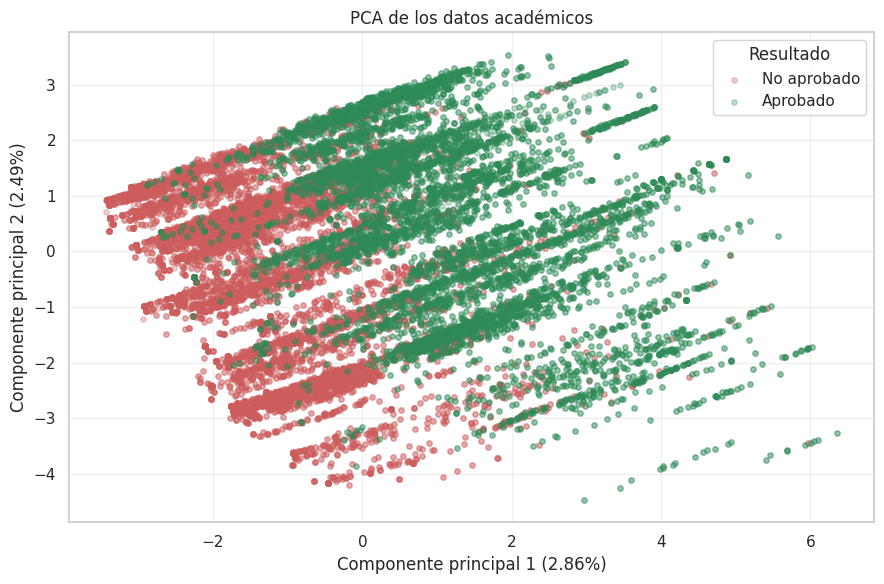

In [36]:
# ============================================================
# 25. GRÁFICO PCA
# ============================================================

y_array = y.to_numpy()

plt.figure(figsize=(9, 6))

for clase, nombre, color in [
    (0, "No aprobado", "indianred"),
    (1, "Aprobado", "seagreen")
]:
    plt.scatter(
        X_pca[y_array == clase, 0],
        X_pca[y_array == clase, 1],
        label=nombre,
        alpha=0.30,
        s=15,
        color=color
    )

plt.xlabel(
    "Componente principal 1 "
    f"({varianza_pca[0]:.2f}%)"
)

plt.ylabel(
    "Componente principal 2 "
    f"({varianza_pca[1]:.2f}%)"
)

plt.title("PCA de los datos académicos")
plt.legend(title="Resultado")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

*Nota: Cada punto representa un registro académico, los puntos verdes corresponden a aprobados y los puntos rojos corresponden a no aprobados.
Una separación visible sugiere que las variables contienen información útil para diferenciar las clases.
La superposición indica que existen casos con características similares, pero resultados diferentes.*

## 6.4. Separación en entrenamiento y prueba

El dataset se dividirá de la siguiente manera:

- 80 % para entrenamiento.
- 20 % para prueba.

Se utilizará `stratify=y` para conservar aproximadamente la misma proporción de aprobados y no aprobados en ambos conjuntos.

El parámetro `random_state=42` permite obtener la misma división cada vez que se ejecuta el código.

In [37]:
# ============================================================
# 26. DIVIDIR ENTRENAMIENTO Y PRUEBA
# ============================================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEMILLA,
        stratify=y
    )
)

print("Datos de entrenamiento:")
print(X_train.shape)

print("\nDatos de prueba:")
print(X_test.shape)

print("\nProporción de aprobados:")

print(
    "Entrenamiento:",
    f"{y_train.mean():.2%}"
)

print(
    "Prueba:",
    f"{y_test.mean():.2%}"
)

Datos de entrenamiento:
(21928, 107)

Datos de prueba:
(5483, 107)

Proporción de aprobados:
Entrenamiento: 44.58%
Prueba: 44.57%


## 6.5. Escalado de variables

Las variables serán estandarizadas mediante `StandardScaler`.

El escalador se ajustará solamente con los datos de entrenamiento. Posteriormente, esa misma transformación se aplicará a los datos de prueba.

Esto evita utilizar información del conjunto de prueba durante el entrenamiento.

In [39]:
# ============================================================
# 27. ESCALAR LOS DATOS
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Dimensión de entrenamiento escalado:",
    X_train_scaled.shape
)

print(
    "Dimensión de prueba escalado:",
    X_test_scaled.shape
)


Dimensión de entrenamiento escalado: (21928, 107)
Dimensión de prueba escalado: (5483, 107)


## 6.6. Interpretación del procesamiento

Se seleccionaron diez variables numéricas y dos variables categóricas para predecir la aprobación.

Las variables categóricas `Carrera` y `Cod.Asign` fueron transformadas mediante One-Hot Encoding. Como resultado, el conjunto de variables predictoras pasó a contener 107 columnas.

PCA se aplicó para representar los datos en dos dimensiones y observar visualmente la distribución de estudiantes aprobados y no aprobados.

Finalmente, los datos se dividieron en 80 % para entrenamiento y 20 % para prueba. Se conservó la proporción de las clases mediante `stratify` y las variables fueron estandarizadas utilizando únicamente la información del conjunto de entrenamiento.

---
# 7. Entrenamiento de modelos

Se entrenarán cuatro modelos de clasificación:

1. Regresión logística.
2. Árbol de decisión.
3. Random Forest.
4. Gradient Boosting.

Todos los modelos recibirán los mismos datos de entrenamiento escalados y serán evaluados con el mismo conjunto de prueba.

Esto permite realizar una comparación directa entre sus resultados.

## 7.1. Regresión logística

Se usará la regresion logistica para calcular la probabilidad de que un estudiante apruebe la asignatura.

Se utilizarán los siguientes parámetros:

- `class_weight="balanced"`: compensa la diferencia entre clases.
- `max_iter=1000`: establece un máximo de 1.000 iteraciones.
- `random_state=42`: permite reproducir los resultados.

In [41]:
# ============================================================
# 28. REGRESIÓN LOGÍSTICA
# ============================================================

modelo_logistico = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEMILLA
)

# Entrenar
modelo_logistico.fit(
    X_train_scaled,
    y_train
)

# Predecir clases
pred_logistico = modelo_logistico.predict(
    X_test_scaled
)

# Predecir probabilidades
prob_logistico = modelo_logistico.predict_proba(
    X_test_scaled
)[:, 1]

print("Modelo 1 entrenado.")

Modelo 1 entrenado.


In [42]:
# ============================================================
# 29. MÉTRICAS DE REGRESIÓN LOGÍSTICA
# ============================================================

accuracy_logistico = accuracy_score(
    y_test,
    pred_logistico
)

precision_logistico = precision_score(
    y_test,
    pred_logistico,
    zero_division=0
)

recall_logistico = recall_score(
    y_test,
    pred_logistico,
    zero_division=0
)

f1_logistico = f1_score(
    y_test,
    pred_logistico,
    zero_division=0
)

auc_logistico = roc_auc_score(
    y_test,
    prob_logistico
)

print("REGRESIÓN LOGÍSTICA\n")

print(
    f"Accuracy: {accuracy_logistico:.4f}"
)

print(
    f"Precision: {precision_logistico:.4f}"
)

print(
    f"Recall: {recall_logistico:.4f}"
)

print(
    f"F1-score: {f1_logistico:.4f}"
)

print(
    f"AUC-ROC: {auc_logistico:.4f}"
)

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_test,
        pred_logistico,
        target_names=[
            "No aprobado",
            "Aprobado"
        ],
        digits=4,
        zero_division=0
    )
)

REGRESIÓN LOGÍSTICA

Accuracy: 0.8685
Precision: 0.8145
Recall: 0.9128
F1-score: 0.8609
AUC-ROC: 0.9444

Reporte de clasificación:

              precision    recall  f1-score   support

 No aprobado     0.9224    0.8328    0.8753      3039
    Aprobado     0.8145    0.9128    0.8609      2444

    accuracy                         0.8685      5483
   macro avg     0.8685    0.8728    0.8681      5483
weighted avg     0.8743    0.8685    0.8689      5483



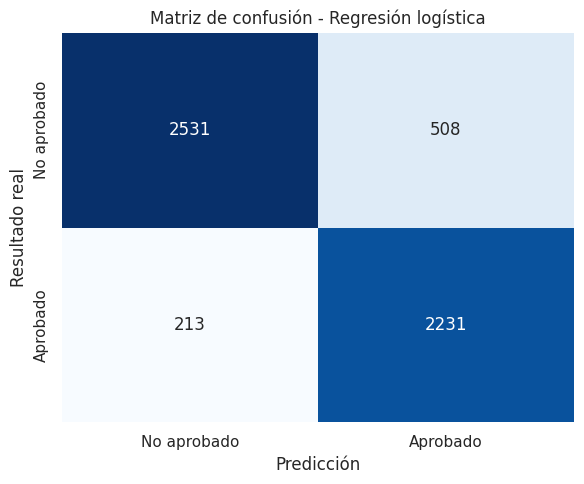

In [43]:
# ============================================================
# 30. MATRIZ DE CONFUSIÓN - REGRESIÓN LOGÍSTICA
# ============================================================

matriz_logistico = confusion_matrix(
    y_test,
    pred_logistico
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No aprobado",
        "Aprobado"
    ],
    yticklabels=[
        "No aprobado",
        "Aprobado"
    ]
)

plt.title(
    "Matriz de confusión - Regresión logística"
)
plt.xlabel("Predicción")
plt.ylabel("Resultado real")

plt.tight_layout()
plt.show()

## 7.2. Árbol de decisión

Puede representar relaciones no lineales entre las calificaciones y la aprobación, también permite construir reglas fáciles de interpretar.

Se utilizarán:

- `max_depth=3`: limita la profundidad del árbol y reduce el sobreajuste.
- `class_weight="balanced"`: compensa la diferencia entre clases.
- `random_state=42`: permite reproducir el resultado.

In [44]:
# ============================================================
# 31. ÁRBOL DE DECISIÓN
# ============================================================

modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=SEMILLA
)

# Entrenar
modelo_arbol.fit(
    X_train_scaled,
    y_train
)

# Predecir clases
pred_arbol = modelo_arbol.predict(
    X_test_scaled
)

# Predecir probabilidades
prob_arbol = modelo_arbol.predict_proba(
    X_test_scaled
)[:, 1]

print("Modelo 2 entrenado.")

Modelo 2 entrenado.


In [45]:
# ============================================================
# 32. MÉTRICAS DEL ÁRBOL DE DECISIÓN
# ============================================================

accuracy_arbol = accuracy_score(
    y_test,
    pred_arbol
)

precision_arbol = precision_score(
    y_test,
    pred_arbol,
    zero_division=0
)

recall_arbol = recall_score(
    y_test,
    pred_arbol,
    zero_division=0
)

f1_arbol = f1_score(
    y_test,
    pred_arbol,
    zero_division=0
)

auc_arbol = roc_auc_score(
    y_test,
    prob_arbol
)

print("ÁRBOL DE DECISIÓN\n")

print(f"Accuracy: {accuracy_arbol:.4f}")
print(f"Precision: {precision_arbol:.4f}")
print(f"Recall: {recall_arbol:.4f}")
print(f"F1-score: {f1_arbol:.4f}")
print(f"AUC-ROC: {auc_arbol:.4f}")

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_test,
        pred_arbol,
        target_names=[
            "No aprobado",
            "Aprobado"
        ],
        digits=4,
        zero_division=0
    )
)

ÁRBOL DE DECISIÓN

Accuracy: 0.8495
Precision: 0.7631
Recall: 0.9607
F1-score: 0.8506
AUC-ROC: 0.9303

Reporte de clasificación:

              precision    recall  f1-score   support

 No aprobado     0.9601    0.7601    0.8485      3039
    Aprobado     0.7631    0.9607    0.8506      2444

    accuracy                         0.8495      5483
   macro avg     0.8616    0.8604    0.8495      5483
weighted avg     0.8723    0.8495    0.8494      5483



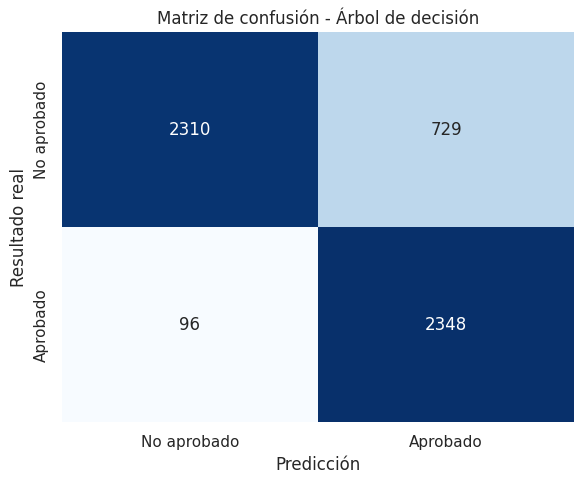

In [46]:
# ============================================================
# 33. MATRIZ DE CONFUSIÓN - ÁRBOL DE DECISIÓN
# ============================================================

matriz_arbol = confusion_matrix(
    y_test,
    pred_arbol
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No aprobado",
        "Aprobado"
    ],
    yticklabels=[
        "No aprobado",
        "Aprobado"
    ]
)

plt.title(
    "Matriz de confusión - Árbol de decisión"
)
plt.xlabel("Predicción")
plt.ylabel("Resultado real")

plt.tight_layout()
plt.show()

## 7.3. Random Forest

Combina numerosos árboles de decisión, entonces produce resultados más estables y reduce el riesgo de sobreajuste de un árbol individual.

Parámetros utilizados:

- `n_estimators=100`: cantidad de árboles.
- `max_depth=3`: profundidad máxima de cada árbol.
- `class_weight="balanced"`: compensa la diferencia entre clases.
- `random_state=42`: permite reproducir el resultado.

In [49]:
# ============================================================
# 34. RANDOM FOREST
# ============================================================

modelo_bosque = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    class_weight="balanced",
    random_state=SEMILLA
)

# Entrenar
modelo_bosque.fit(
    X_train_scaled,
    y_train
)

# Predecir clases
pred_bosque = modelo_bosque.predict(
    X_test_scaled
)

# Predecir probabilidades
prob_bosque = modelo_bosque.predict_proba(
    X_test_scaled
)[:, 1]

print("Modelo 3 entrenado.")

Modelo 3 entrenado.


In [50]:
# ============================================================
# 35. MÉTRICAS DE RANDOM FOREST
# ============================================================

accuracy_bosque = accuracy_score(
    y_test,
    pred_bosque
)

precision_bosque = precision_score(
    y_test,
    pred_bosque,
    zero_division=0
)

recall_bosque = recall_score(
    y_test,
    pred_bosque,
    zero_division=0
)

f1_bosque = f1_score(
    y_test,
    pred_bosque,
    zero_division=0
)

auc_bosque = roc_auc_score(
    y_test,
    prob_bosque
)

print("RANDOM FOREST\n")

print(f"Accuracy: {accuracy_bosque:.4f}")
print(f"Precision: {precision_bosque:.4f}")
print(f"Recall: {recall_bosque:.4f}")
print(f"F1-score: {f1_bosque:.4f}")
print(f"AUC-ROC: {auc_bosque:.4f}")

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_test,
        pred_bosque,
        target_names=[
            "No aprobado",
            "Aprobado"
        ],
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST

Accuracy: 0.8497
Precision: 0.7840
Recall: 0.9149
F1-score: 0.8444
AUC-ROC: 0.9218

Reporte de clasificación:

              precision    recall  f1-score   support

 No aprobado     0.9209    0.7973    0.8547      3039
    Aprobado     0.7840    0.9149    0.8444      2444

    accuracy                         0.8497      5483
   macro avg     0.8525    0.8561    0.8495      5483
weighted avg     0.8599    0.8497    0.8501      5483



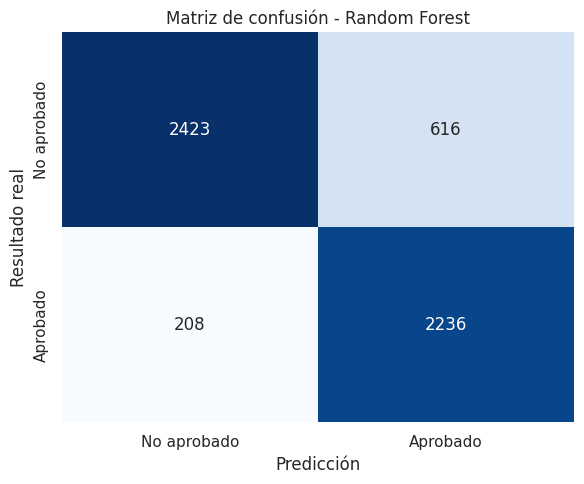

In [51]:
# ============================================================
# 36. MATRIZ DE CONFUSIÓN - RANDOM FOREST
# ============================================================

matriz_bosque = confusion_matrix(
    y_test,
    pred_bosque
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_bosque,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No aprobado",
        "Aprobado"
    ],
    yticklabels=[
        "No aprobado",
        "Aprobado"
    ]
)

plt.title(
    "Matriz de confusión - Random Forest"
)
plt.xlabel("Predicción")
plt.ylabel("Resultado real")

plt.tight_layout()
plt.show()

## 7.4. Gradient Boosting

Gradient Boosting construye árboles de manera secuencial. Cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Parámetros utilizados:

- `n_estimators=100`: cantidad de estimadores.
- `learning_rate=0.1`: contribución de cada árbol.
- `max_depth=3`: profundidad máxima.
- `random_state=42`: permite reproducir el resultado.

In [53]:
# ============================================================
# 37. GRADIENT BOOSTING
# ============================================================

modelo_gradient = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=SEMILLA
)

# Entrenar
modelo_gradient.fit(
    X_train_scaled,
    y_train
)

# Predecir clases
pred_gradient = modelo_gradient.predict(
    X_test_scaled
)

# Predecir probabilidades
prob_gradient = modelo_gradient.predict_proba(
    X_test_scaled
)[:, 1]

print("Modelo 4 entrenado.")

Modelo 4 entrenado.


In [55]:
# ============================================================
# 38. MÉTRICAS DE GRADIENT BOOSTING
# ============================================================

accuracy_gradient = accuracy_score(
    y_test,
    pred_gradient
)

precision_gradient = precision_score(
    y_test,
    pred_gradient,
    zero_division=0
)

recall_gradient = recall_score(
    y_test,
    pred_gradient,
    zero_division=0
)

f1_gradient = f1_score(
    y_test,
    pred_gradient,
    zero_division=0
)

auc_gradient = roc_auc_score(
    y_test,
    prob_gradient
)

print("GRADIENT BOOSTING\n")

print(f"Accuracy: {accuracy_gradient:.4f}")
print(f"Precision: {precision_gradient:.4f}")
print(f"Recall: {recall_gradient:.4f}")
print(f"F1-score: {f1_gradient:.4f}")
print(f"AUC-ROC: {auc_gradient:.4f}")

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_test,
        pred_gradient,
        target_names=[
            "No aprobado",
            "Aprobado"
        ],
        digits=4,
        zero_division=0
    )
)

GRADIENT BOOSTING

Accuracy: 0.8758
Precision: 0.8488
Recall: 0.8777
F1-score: 0.8630
AUC-ROC: 0.9520

Reporte de clasificación:

              precision    recall  f1-score   support

 No aprobado     0.8988    0.8743    0.8864      3039
    Aprobado     0.8488    0.8777    0.8630      2444

    accuracy                         0.8758      5483
   macro avg     0.8738    0.8760    0.8747      5483
weighted avg     0.8766    0.8758    0.8760      5483



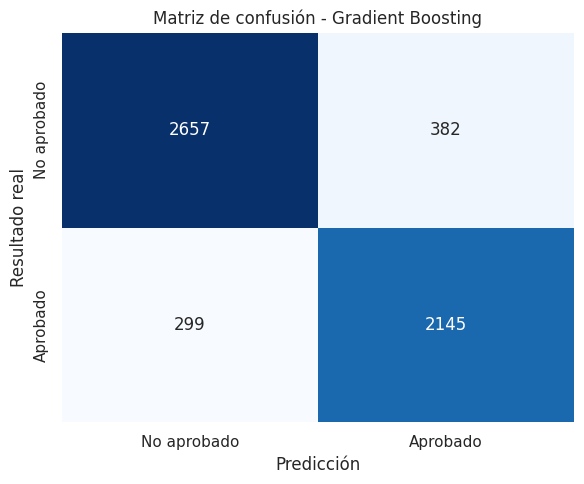

In [56]:
# ============================================================
# 39. MATRIZ DE CONFUSIÓN - GRADIENT BOOSTING
# ============================================================

matriz_gradient = confusion_matrix(
    y_test,
    pred_gradient
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_gradient,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No aprobado",
        "Aprobado"
    ],
    yticklabels=[
        "No aprobado",
        "Aprobado"
    ]
)

plt.title(
    "Matriz de confusión - Gradient Boosting"
)
plt.xlabel("Predicción")
plt.ylabel("Resultado real")

plt.tight_layout()
plt.show()

# 8. Comparación de los modelos

Después de entrenar y evaluar individualmente los cuatro modelos, sus métricas se organizan en una tabla comparativa.

El mejor modelo se selecciona considerando principalmente AUC-ROC y F1-score.

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,Gradient Boosting,0.8758,0.8488,0.8777,0.8630,0.9520
1,Regresión logística,0.8685,0.8145,0.9128,0.8609,0.9444
2,Árbol de decisión,0.8495,0.7631,0.9607,0.8506,0.9303
3,Random Forest,0.8497,0.7840,0.9149,0.8444,0.9218


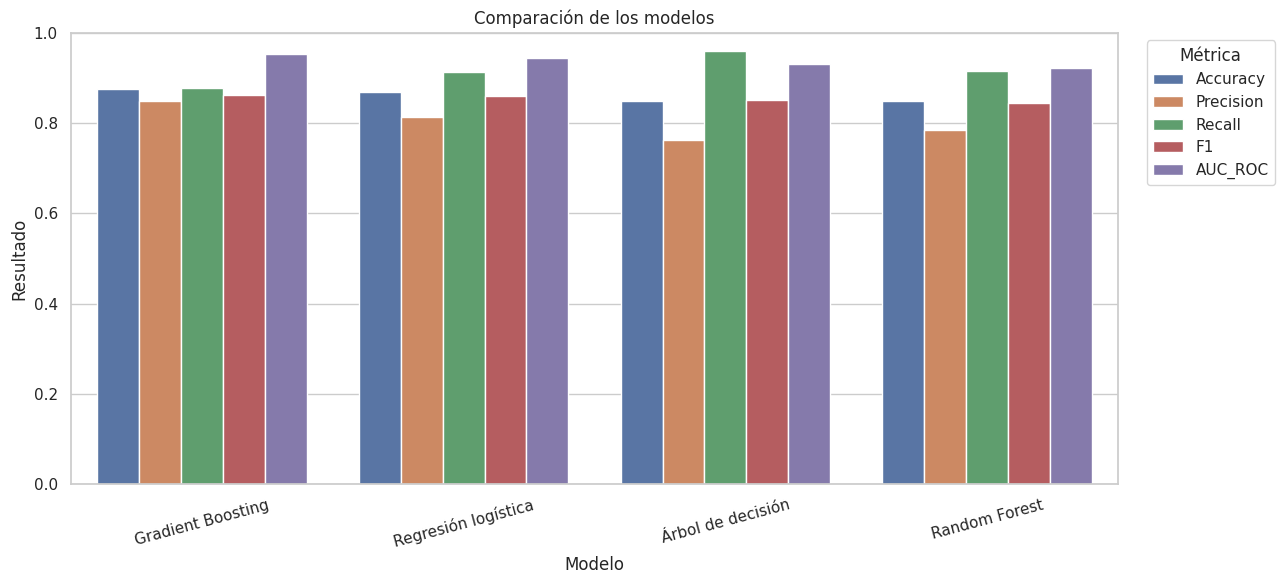

In [58]:
# ============================================================
# 40. TABLA COMPARATIVA
# ============================================================

resultados = [
    {
        "Modelo": "Regresión logística",
        "Accuracy": accuracy_logistico,
        "Precision": precision_logistico,
        "Recall": recall_logistico,
        "F1": f1_logistico,
        "AUC_ROC": auc_logistico
    },
    {
        "Modelo": "Árbol de decisión",
        "Accuracy": accuracy_arbol,
        "Precision": precision_arbol,
        "Recall": recall_arbol,
        "F1": f1_arbol,
        "AUC_ROC": auc_arbol
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_bosque,
        "Precision": precision_bosque,
        "Recall": recall_bosque,
        "F1": f1_bosque,
        "AUC_ROC": auc_bosque
    },
    {
        "Modelo": "Gradient Boosting",
        "Accuracy": accuracy_gradient,
        "Precision": precision_gradient,
        "Recall": recall_gradient,
        "F1": f1_gradient,
        "AUC_ROC": auc_gradient
    }
]

tabla_resultados = pd.DataFrame(
    resultados
)

tabla_resultados = tabla_resultados.sort_values(
    by=["AUC_ROC", "F1"],
    ascending=False
).reset_index(drop=True)

display(
    tabla_resultados.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC_ROC": "{:.4f}"
    })
)

# ============================================================
# 41. GRÁFICO COMPARATIVO
# ============================================================

datos_grafico = tabla_resultados.melt(
    id_vars="Modelo",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC_ROC"
    ],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=datos_grafico,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# 42. SELECCIONAR EL MEJOR MODELO
# ============================================================

mejor_nombre = tabla_resultados.iloc[0][
    "Modelo"
]

modelos_entrenados = {
    "Regresión logística": modelo_logistico,
    "Árbol de decisión": modelo_arbol,
    "Random Forest": modelo_bosque,
    "Gradient Boosting": modelo_gradient
}

probabilidades_modelos = {
    "Regresión logística": prob_logistico,
    "Árbol de decisión": prob_arbol,
    "Random Forest": prob_bosque,
    "Gradient Boosting": prob_gradient
}

mejor_modelo = modelos_entrenados[
    mejor_nombre
]

print("Mejor modelo:")
print(mejor_nombre)

print("\nResultados:")

display(
    tabla_resultados.iloc[[0]].style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC_ROC": "{:.4f}"
    })
)

Mejor modelo:
Gradient Boosting

Resultados:


,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,Gradient Boosting,0.8758,0.8488,0.8777,0.8630,0.9520


# 9. Comprobación de la pregunta de investigación

La pregunta del proyecto es:

> ¿Qué asignaturas presentan mayor y menor éxito académico en cada carrera de la FIUNA para el Plan 2023?

Para responder trabajaremos exclusivamente con el mejor modelo obtenido

In [60]:
# ============================================================
# 43. RESULTADOS DEL MEJOR MODELO
# ============================================================

resultados_test = df.loc[
    X_test.index,
    [
        "Carrera",
        "Cod.Asign",
        "Asignatura"
    ]
].copy()

# Incorporar el resultado real
resultados_test["Aprobado_real"] = (
    y_test.to_numpy()
)

# Incorporar la probabilidad calculada
resultados_test["Probabilidad_predicha"] = (
    probabilidades_modelos[mejor_nombre]
)

print("Mejor modelo utilizado:")
print(mejor_nombre)

print("\nCantidad de registros de prueba:")
print(len(resultados_test))

display(resultados_test.head(10))

Mejor modelo utilizado:
Gradient Boosting

Cantidad de registros de prueba:
5483


,Carrera,Cod.Asign,Asignatura,Aprobado_real,Probabilidad_predicha
36990,IND,23023,ALGEBRA LINEAL,1,0.590
16324,CIV,23014,ALGEBRA MODERNA,0,0.012
59109,MEC,23041,METODOS NUMERICOS,1,0.765
58598,CIV,23035,ESTATICA,1,0.829
35395,ELE,23021,OPTICA Y ONDAS,0,0.007
56578,IND,23031,ELECTRICIDAD Y MAGNETISMO,0,0.241
54831,CIV,23015,GEOMETRIA DESCRIPTIVA,1,0.971
38424,IND,23025,QUIMICA GENERAL,1,0.804
53476,CIV,23013,GEOMETRIA VECTORIAL,0,0.012
60223,CIV,23152,MECANICA DE MATERIALES 2,1,0.560


## 9.1. Tasas reales y predichas por asignatura

Para cada combinación carrera–asignatura se calcularán:

- Cantidad de registros de prueba.
- Cantidad de aprobados reales.
- Tasa real de aprobación.
- Tasa predicha de aprobación.
- Error absoluto entre ambas tasas.

La tasa predicha se obtendrá mediante el promedio de las probabilidades individuales.

In [61]:
# ============================================================
# 44. TASAS REALES Y PREDICHAS POR ASIGNATURA
# ============================================================

resultados_por_materia = (
    resultados_test.groupby(
        [
            "Carrera",
            "Cod.Asign",
            "Asignatura"
        ]
    )
    .agg(
        Registros=("Aprobado_real", "size"),
        Aprobados=("Aprobado_real", "sum"),
        Tasa_real=(
            "Aprobado_real",
            "mean"
        ),
        Tasa_predicha=(
            "Probabilidad_predicha",
            "mean"
        )
    )
    .reset_index()
)

# Convertir las proporciones a porcentajes
resultados_por_materia["Tasa_real"] = (
    resultados_por_materia["Tasa_real"]
    * 100
)

resultados_por_materia["Tasa_predicha"] = (
    resultados_por_materia["Tasa_predicha"]
    * 100
)

# Calcular el error
resultados_por_materia["Error_absoluto"] = abs(
    resultados_por_materia["Tasa_real"]
    - resultados_por_materia["Tasa_predicha"]
)

display(resultados_por_materia.head(10))

,Carrera,Cod.Asign,Asignatura,Registros,Aprobados,Tasa_real,Tasa_predicha,Error_absoluto
0,CGF,23011,MECANICA Y CALOR,3,1,33.333,21.405,11.928
1,CGF,23012,CALCULO 1,11,4,36.364,22.779,13.585
2,CGF,23013,GEOMETRIA VECTORIAL,3,3,100.000,94.234,5.766
3,CGF,23014,ALGEBRA MODERNA,4,0,0.000,2.308,2.308
4,CGF,23015,GEOMETRIA DESCRIPTIVA,13,4,30.769,46.968,16.199
5,CGF,23016,DIBUJO TECNICO,7,3,42.857,42.092,0.765
6,CGF,23021,OPTICA Y ONDAS,10,1,10.000,3.382,6.618
7,CGF,23022,CALCULO 2,7,3,42.857,29.204,13.654
8,CGF,23023,ALGEBRA LINEAL,20,3,15.000,15.116,0.116
9,CGF,23024,FUNDAMENTOS DE PROGRAMACION,15,4,26.667,22.927,3.739


## 9.2. Selección de grupos representativos

Para esta comprobación se utilizarán solamente las combinaciones carrera–asignatura con al menos 10 registros dentro del conjunto de prueba.

Se utiliza un mínimo de 10, en lugar de 20, porque el conjunto de prueba contiene solamente el 20 % del dataset completo.

Este filtro mantiene representadas las siete carreras.

In [62]:
# ============================================================
# 45. FILTRAR GRUPOS PEQUEÑOS
# ============================================================

MINIMO_PRUEBA = 10

resultados_validos = (
    resultados_por_materia[
        resultados_por_materia["Registros"]
        >= MINIMO_PRUEBA
    ]
    .copy()
)

print(
    "Grupos antes del filtro:",
    len(resultados_por_materia)
)

print(
    "Grupos después del filtro:",
    len(resultados_validos)
)

print(
    "Carreras representadas:",
    resultados_validos["Carrera"].nunique()
)

Grupos antes del filtro: 192
Grupos después del filtro: 123
Carreras representadas: 7


## 9.3. Comparación entre tasas reales y predichas

Se utilizan dos valores para comprobar si el modelo reproduce el éxito académico de las materias:

### Error absoluto medio

Indica cuántos puntos porcentuales separan, en promedio, la tasa real y la predicha.

### Correlación

Indica si las materias con mayor tasa real también reciben tasas predichas mayores.

La correlación puede tomar valores entre -1 y 1:

- Cercana a 1: relación positiva fuerte.
- Cercana a 0: ausencia de relación lineal.
- Cercana a -1: relación negativa fuerte.

In [63]:
# ============================================================
# 46. COMPROBAR LAS TASAS PREDICHAS
# ============================================================

error_medio = (
    resultados_validos[
        "Error_absoluto"
    ].mean()
)

correlacion = (
    resultados_validos[
        "Tasa_real"
    ].corr(
        resultados_validos[
            "Tasa_predicha"
        ]
    )
)

print(
    "Error absoluto medio:",
    f"{error_medio:.2f} puntos porcentuales"
)

print(
    "Correlación entre tasas reales y predichas:",
    f"{correlacion:.4f}"
)

Error absoluto medio: 5.40 puntos porcentuales
Correlación entre tasas reales y predichas: 0.9399


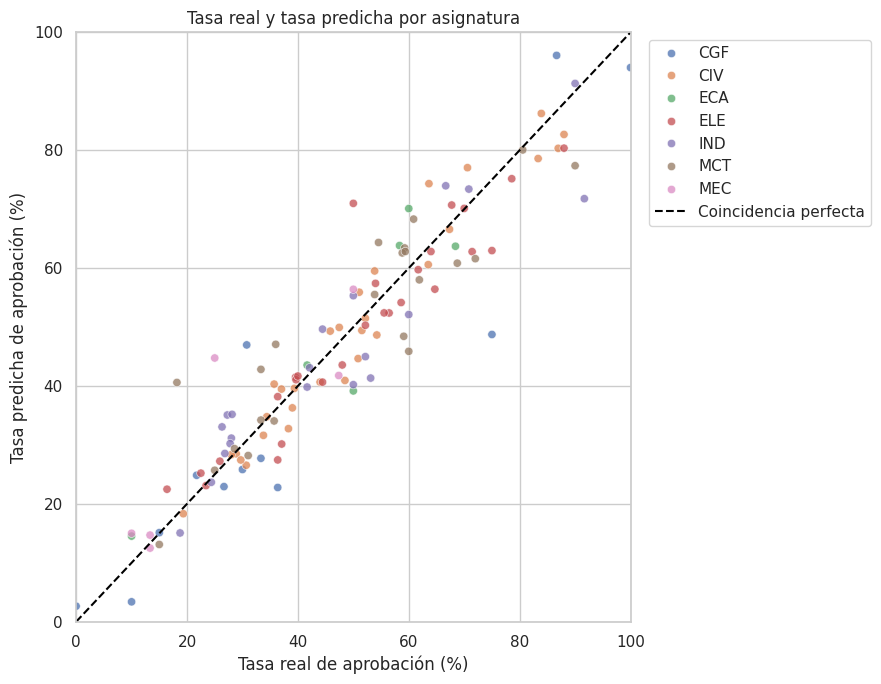

In [64]:
# ============================================================
# 47. GRÁFICO DE TASAS REALES Y PREDICHAS
# ============================================================

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=resultados_validos,
    x="Tasa_real",
    y="Tasa_predicha",
    hue="Carrera",
    alpha=0.75
)

# Línea de coincidencia perfecta
plt.plot(
    [0, 100],
    [0, 100],
    color="black",
    linestyle="--",
    label="Coincidencia perfecta"
)

plt.title(
    "Tasa real y tasa predicha por asignatura"
)

plt.xlabel("Tasa real de aprobación (%)")
plt.ylabel("Tasa predicha de aprobación (%)")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 9.4. Asignaturas con mayor y menor éxito

Se mostrarán las cinco asignaturas con mayor y menor tasa real de aprobación dentro de cada carrera.

Junto a la tasa real se mostrará la tasa estimada por el mejor modelo. Esto permite comprobar si la predicción sigue el comportamiento observado.

In [66]:
# ============================================================
# 48. RESPUESTA GENERADA POR EL MEJOR MODELO
# ============================================================

columnas_mostrar = [
    "Asignatura",
    "Registros",
    "Tasa_predicha",
    "Tasa_real",
    "Error_absoluto"
]

for carrera in sorted(
    resultados_validos["Carrera"].unique()
):
    datos_carrera = resultados_validos[
        resultados_validos["Carrera"]
        == carrera
    ]

    # Ordenar según las predicciones del modelo
    mayor_exito_predicho = (
        datos_carrera
        .sort_values(
            "Tasa_predicha",
            ascending=False
        )
        .head(5)
    )

    menor_exito_predicho = (
        datos_carrera
        .sort_values(
            "Tasa_predicha",
            ascending=True
        )
        .head(5)
    )

    print("=" * 70)
    print(f"CARRERA: {carrera}")
    print("=" * 70)

    print(
        "\nAsignaturas con mayor éxito "
        "según el modelo:"
    )

    display(
        mayor_exito_predicho[
            columnas_mostrar
        ]
        .style.format({
            "Tasa_predicha": "{:.2f}%",
            "Tasa_real": "{:.2f}%",
            "Error_absoluto": "{:.2f}"
        })
    )

    print(
        "\nAsignaturas con menor éxito "
        "según el modelo:"
    )

    display(
        menor_exito_predicho[
            columnas_mostrar
        ]
        .style.format({
            "Tasa_predicha": "{:.2f}%",
            "Tasa_real": "{:.2f}%",
            "Error_absoluto": "{:.2f}"
        })
    )

CARRERA: CGF

Asignaturas con mayor éxito según el modelo:


,Asignatura,Registros,Tasa_predicha,Tasa_real,Error_absoluto
22,GEOLOGIA DEL PARAGUAY,15,96.09%,86.67%,9.42
20,FOTOGRAMETRIA 1,10,94.02%,100.00%,5.98
17,FISICO-QUIMICA AMBIENTAL,16,48.74%,75.00%,26.26
4,GEOMETRIA DESCRIPTIVA,13,46.97%,30.77%,16.20
12,ECUACIONES DIFERENCIALES,24,27.73%,33.33%,5.60



Asignaturas con menor éxito según el modelo:


,Asignatura,Registros,Tasa_predicha,Tasa_real,Error_absoluto
11,ELECTRICIDAD Y MAGNETISMO,17,2.64%,0.00%,2.64
6,OPTICA Y ONDAS,10,3.38%,10.00%,6.62
8,ALGEBRA LINEAL,20,15.12%,15.00%,0.12
1,CALCULO 1,11,22.78%,36.36%,13.58
9,FUNDAMENTOS DE PROGRAMACION,15,22.93%,26.67%,3.74


CARRERA: CIV

Asignaturas con mayor éxito según el modelo:


...

,Asignatura,Registros,Tasa_predicha,Tasa_real,Error_absoluto
150,METODOS NUMERICOS,20,13.11%,15.00%,1.89
149,ESTATICA,48,25.70%,25.00%,0.70
145,ELECTRICIDAD Y MAGNETISMO,29,28.20%,31.03%,2.84
138,CALCULO 1,49,29.37%,28.57%,0.79
143,ALGEBRA LINEAL,28,34.07%,35.71%,1.65


CARRERA: MEC

Asignaturas con mayor éxito según el modelo:


,Asignatura,Registros,Tasa_predicha,Tasa_real,Error_absoluto
168,GEOMETRIA VECTORIAL,10,56.41%,50.00%,6.41
179,PROBABILIDAD,12,44.75%,25.00%,19.75
167,CALCULO 1,19,41.78%,47.37%,5.59
185,MECANICA DE MATERIALES 1,10,15.01%,10.00%,5.01
177,ELECTRICIDAD Y MAGNETISMO,15,14.70%,13.33%,1.37



Asignaturas con menor éxito según el modelo:


,Asignatura,Registros,Tasa_predicha,Tasa_real,Error_absoluto
182,METODOS NUMERICOS,15,12.49%,13.33%,0.84
177,ELECTRICIDAD Y MAGNETISMO,15,14.70%,13.33%,1.37
185,MECANICA DE MATERIALES 1,10,15.01%,10.00%,5.01
167,CALCULO 1,19,41.78%,47.37%,5.59
179,PROBABILIDAD,12,44.75%,25.00%,19.75


## 9.4. Respuesta a la pregunta de investigación

El mejor modelo calcula una probabilidad de aprobación para cada registro del conjunto de prueba.

Para responder la pregunta de investigación, estas probabilidades se promedian por carrera y asignatura.

Las asignaturas con las mayores probabilidades promedio se consideran las de mayor éxito académico estimado. Las asignaturas con las menores probabilidades promedio se consideran las de menor éxito académico estimado.

Las tasas reales se presentan únicamente como referencia para comprobar la proximidad de las predicciones.

# 10. Conclusiones

El proyecto comparó cuatro modelos de Machine Learning para predecir la aprobación de estudiantes de la FIUNA pertenecientes al Plan 2023. Se utilizaron 27.411 registros académicos correspondientes a los periodos 2024-2, 2025-1 y 2025-2.

La variable objetivo fue la aprobación de una asignatura, representada mediante dos clases: aprobado y no aprobado. Como variables predictoras se utilizaron la carrera, asignatura, curso, convocatoria, año, semestre y los resultados académicos disponibles antes del examen final.

Los modelos evaluados fueron regresión logística, árbol de decisión, Random Forest y Gradient Boosting. La comparación se realizó mediante Accuracy, Precision, Recall, F1-score y AUC-ROC.

Gradient Boosting obtuvo el mejor desempeño general, por lo que fue seleccionado para responder la pregunta de investigación.

El modelo calculó una probabilidad de aprobación para cada registro de prueba. Posteriormente, estas probabilidades se agruparon por carrera y asignatura. Las materias con las probabilidades promedio más altas fueron identificadas como aquellas con mayor éxito académico estimado, mientras que las materias con las probabilidades más bajas fueron identificadas como aquellas con menor éxito estimado.

La comparación entre las tasas predichas y las tasas reales produjo un error promedio reducido y una correlación positiva fuerte. Esto indica que el mejor modelo reproduce adecuadamente la tendencia observada en el éxito académico de las asignaturas.

Por tanto, la pregunta inicial fue respondida mediante las probabilidades generadas por Gradient Boosting.

Una probabilidad baja de aprobación no demuestra que una asignatura sea intrínsecamente difícil. El resultado indica que, según las variables analizadas y el modelo entrenado, esa asignatura presenta una menor probabilidad estimada de aprobación.